In [21]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import math as m
from turnpike import solve_incomplete_turnpike
from turnpike_combined import solve_turnpike_combined
from itertools import combinations


## Define Class with all the relevant physics

In [2]:
class LSZ_experiment():

    def __init__(self, n_qubits, epsilon, H_target_dictionary, ramp_time, wait_time):
        '''
        Params:
        epsilon: Coefficient of X Hamiltonian
        alpha: Coefficient of target Hamiltonian
        total_time: Total time of the algorithm
        wait_time: Waiting time in the middle of the LSZ algorithm (0 if just doing LZ)
        max_s: maximum of s parameter. Will control slope of schedule
        '''

        self.n_qubits = n_qubits
        self.e = epsilon
        self.Ht_dict = H_target_dictionary

        self.to =  0
        self.tw = wait_time
        self.tr = ramp_time
        
        self.tf = 2*self.tr + self.tw
       
        self.slope = 1/self.tr

        self.npsx, self.npsy, self.npsz = np.array([[0, 1], [1, 0]]), np.array([[0, -1j], [1j, 0]]), np.array([[1, 0], [0, -1]])
        self.qtsx, self.qtsy, self.qtsz = qt.sigmax(), qt.sigmay(), qt.sigmaz() 

        self.ket0 = qt.basis(2, 0)
        self.ket1 = qt.basis(2, 1)


        self.qtsx_list, self.qtsy_list, self.qtsz_list = self.initialize_qt_operators()
        self.npsx_list, self.npsy_list, self.npsz_list = self.initialize_np_operators()

        self.H0_numpy = self.build_H0_numpy()
        self.H0_qutip = self.build_H0_qutip()

        self.Ht_numpy = self.build_Ht_numpy()
        self.Ht_qutip = self.build_Ht_qutip()

    
    def kron_n(self, ops):
        '''Tensor product of a list of operators'''
        out = ops[0]
        for A in ops[1:]:
            out = np.kron(out, A)
        return out
    
    def build_H0_numpy(self):
        H = np.zeros((2**self.n_qubits, 2**self.n_qubits))
        for i in range(self.n_qubits):
            H += -self.e*self.npsx_list[i]
        return H

    def build_H0_qutip(self):
        H = 0
        for i in range(self.n_qubits):
            H += -self.e*self.qtsx_list[i]
        return H
    
    def build_Ht_numpy(self):
        #Initialize Hamiltonian
        H = np.zeros((2**self.n_qubits, 2**self.n_qubits))
        local_z_terms = self.Ht_dict['one_body']

        #Add 1-body terms
        for i, weight in enumerate(local_z_terms):
            H += weight*self.npsz_list[i]

        #Add 2-body terms only if more than 1 qubit
        if self.n_qubits > 1:
            zz_terms = self.Ht_dict['two_body']

            #Apply to all qubit pairs 
            k = 0
            for i in range(self.n_qubits-1):
                for j in range(i+1, self.n_qubits):
                    H += zz_terms[k] * self.npsz_list[i] @ self.npsz_list[j]
                    k += 1

        return H

    def build_Ht_qutip(self):
        #Initialize Hamiltonian
        H = 0
        local_z_terms = self.Ht_dict['one_body']

        #Add 1-body terms
        for i, weight in enumerate(local_z_terms):
            H += weight*self.qtsz_list[i]

        #Add 2-body terms only if more than 1 qubit
        if self.n_qubits > 1:
            zz_terms = self.Ht_dict['two_body']

            #Apply to all qubit pairs
            k = 0
            for i in range(self.n_qubits-1):
                for j in range(i+1, self.n_qubits):
                    H += zz_terms[k] * self.qtsz_list[i] * self.qtsz_list[j]
                    k += 1

        return H

    def initialize_np_operators(self):
        '''Setup operators for individual qubits
            for each value of i it puts the paulis in different positions of the list, 
            then does IxIxI...sigma_ixIxI...xI
        '''
        sx_list, sy_list, sz_list = [], [], []
        sx, sy, sz = self.npsx, self.npsy, self.npsz
        for i in range(self.n_qubits):
            #list of 2x2 identity matrices
            op_list = [np.eye(2) for _ in range(self.n_qubits)]
            #replace i-th element with sigma_x
            op_list[i] = sx
            #create matrices of 2^Nx2^N
            sx_list.append(self.kron_n(op_list))
            #do the same for sigma_y and sigma_z
            op_list[i] = sy
            sy_list.append(self.kron_n(op_list))
            op_list[i] = sz
            sz_list.append(self.kron_n(op_list))

        return sx_list, sy_list, sz_list

    def initialize_qt_operators(self):
        '''Setup operators for individual qubits
            for each value of i it puts the paulis in different positions of the list, 
            then does IxIxI...sigma_ixIxI...xI
        '''
        sx_list, sy_list, sz_list = [], [], []
        sx, sy, sz = self.qtsx, self.qtsy, self.qtsz
        for i in range(self.n_qubits):
            #list of 2x2 identity matrices
            op_list = [qt.qeye(2)] * self.n_qubits
            #replace i-th element with sigma_x
            op_list[i] = sx
            #create matrices of 2^Nx2^N
            sx_list.append(qt.tensor(op_list))
            #do the same for sigma_y and sigma_z
            op_list[i] = sy
            sy_list.append(qt.tensor(op_list))
            op_list[i] = sz
            sz_list.append(qt.tensor(op_list))

        return sx_list, sy_list, sz_list


    def trapezoid_s(self, t):
        return np.minimum(1, self.slope * np.minimum(t, self.tf - t))

    def H_numpy(self, t):
        s = self.trapezoid_s(t)
        return (1-s)*self.H0_numpy + s*self.Ht_numpy
    
    def H_qutip(self):

        H = [[self.H0_qutip, lambda t, args: 1 - self.trapezoid_s(t)], [self.Ht_qutip, lambda t, args: self.trapezoid_s(t)]]

        return H
    
    
    def show_schedule(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        s_list = np.zeros(len(t_list))

        for i,t in enumerate(t_list):
            s_list[i] = self.trapezoid_s(t)
        
        return t_list, s_list
    
    def show_spectrum(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        eg_val_list = []
        eg_vec_list = []

       #Diagonalize for each time step 
        for i,t in enumerate(t_list):
            H = self.H_numpy(t)
            egvals, egvecs = np.linalg.eigh(H)

            eg_val_list.append(egvals)
            eg_vec_list.append(egvecs)

        return t_list, eg_val_list, eg_vec_list
    

    def time_evolution(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)

        #Prepare ground state of H at time 0
        psi0 = qt.tensor([1/np.sqrt(2)*(self.ket0 + self.ket1)]*self.n_qubits)

        #Initialize qutip Hamiltonian
        H = self.H_qutip()

        #Time evolution
        return qt.sesolve(H, psi0, t_list)
    
    def calculate_populations(self, sim_res):

        final_state = sim_res.states[-1].full().flatten()

        H_f = self.H_numpy(self.tf)
        eigvals_f, eigvecs_f = np.linalg.eigh(H_f)

        # eigvecs_f columns are eigenvectors; eigvecs_f[:, k] is the k-th eigenvector
        n_states = 2**self.n_qubits
        populations = np.zeros(n_states)
        for k in range(n_states):
            overlap = np.dot(eigvecs_f[:, k].conj(), final_state)
            populations[k] = np.real(overlap * overlap.conj())

        return populations



- Ramp time controls the speed that we use to bring the system to the middle point. The faster, the higher the transition probability.

- High ramp time makes oscillations larger

- for LZ we ramp and pass the crossing once. For LZS you cross the gap twice. during wait time, s=1, no transverse term. Start at Hx, both terms evolve.


## Define parameters of experiment

In [3]:
epsilon = 4
alpha = 1
ramp_time = 1
n_steps = 201

#1 qubit example
# local_z_list = np.array([1])
# zz_terms = np.array([])

#2 qubit example
local_z_list = np.array([2,1.1])
zz_terms = np.array([0.35])

#3 qubit example
# local_z_list = np.array([2.1, 3.05, 1.78])
# zz_terms = np.array([1.22, 0.54, 2.1])

#4 qubit example
# local_z_list = np.array([1.1, 2.05, 1.44, 0.93])
# zz_terms = np.array([2.82, 1.24, 0.36, 3.22, 1.48, 3.20])

nqubits = len(local_z_list)
max_wait_time = 50.0/alpha
n_sims = int(max_wait_time*20)

tw_l = np.linspace(0, max_wait_time, n_sims)
pc_list = []
pe_list = []


H_target_dict = {'one_body': local_z_list, 'two_body': zz_terms}

wait_test = 0
test =LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, wait_test)

print(max_wait_time)
print(n_sims)

50.0
1000


## Plot example schedue

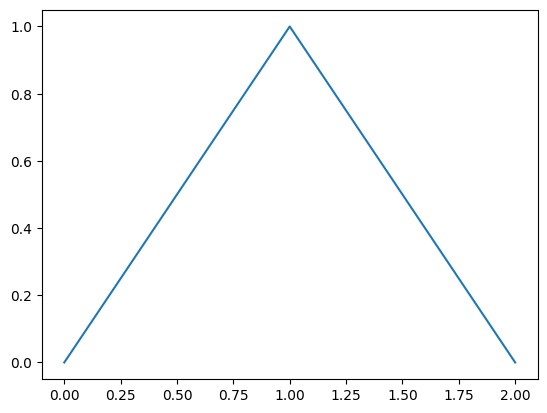

In [4]:
t_list, s_list = test.show_schedule(n_steps)
plt.plot(t_list, s_list)

## Plot evolution of real spectrum

[-2.75 -1.25  0.55  3.45]


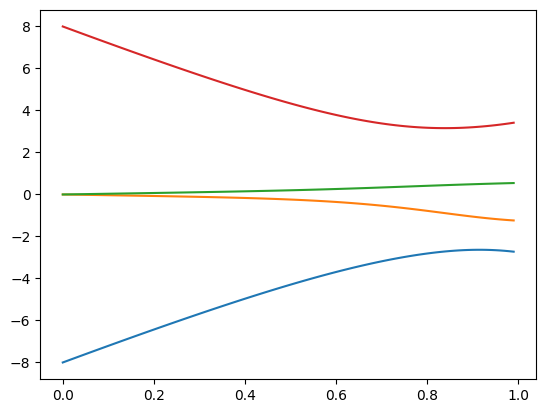

In [5]:
t_list, egvals, egvecs = test.show_spectrum(n_steps)
midpoint = int(len(t_list)/2)
plt.plot(t_list[0:midpoint], egvals[0:midpoint])

print(egvals[midpoint])

## Run loop over all waiting times

In [6]:
for wait_time in tw_l:
    experiment =LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, wait_time)

    n_steps = int((ramp_time*2 + wait_time)*51)
    
    result = experiment.time_evolution(n_steps)

    populations = experiment.calculate_populations(result)

    pc_list.append(np.real(populations[0]))

### Definition of Fourier analysis function

In [7]:
def fourier_analysis(pc_list, tw_l, n_peaks=15, prominence_threshold=0.01,
                     zero_pad_factor=32, window='hann'):
    """
    High-resolution spectral analysis returning frequencies, amplitudes, and phases
    of all detected modes.

    Techniques used
    ---------------
    - DC removal   : subtract mean before windowing to prevent the DC offset
                     from creating a spurious low-frequency spectral hump.
    - Hann window  : suppresses spectral leakage from finite observation window.
    - Zero-padding : interpolates the DFT grid by `zero_pad_factor` for sub-bin
                     frequency resolution without adding information.
    - Parabolic interpolation : refines each peak to sub-bin accuracy using the
                     three-point parabola on log-magnitude.
    - Phase recovery : reads the complex FFT phase at the detected bin,
                     corrected for the time-axis offset.

    Parameters
    ----------
    pc_list : array-like
        Real-valued signal (e.g. ground-state population over time).
    tw_l : array-like
        Uniformly spaced time axis.
    n_peaks : int
        Maximum number of modes to return.
    prominence_threshold : float
        Discard peaks whose amplitude is below this fraction of the largest peak.
    zero_pad_factor : int
        Total length of the zero-padded signal = zero_pad_factor * N.
        Higher values give finer frequency grid (8-16 recommended).
    window : str
        Window function passed to ``scipy.signal.get_window``.

    Returns
    -------
    experimental_freqs : np.ndarray   shape (K,)
        Frequencies [same units as 1/tw_l], sorted by amplitude descending.
    amplitudes : np.ndarray    shape (K,)
        Peak amplitudes (corrected for window energy loss).
    phases : np.ndarray        shape (K,)
        Phases in radians, referenced to the start of the time axis.
    """
    from scipy.signal import find_peaks, get_window

    y = np.asarray(pc_list, dtype=float)
    t = np.asarray(tw_l, dtype=float)
    N = len(y)
    dt = t[1] - t[0]
    dc = y.mean()

    # --- DC removal THEN window ---
    # Must subtract mean before applying window; otherwise the DC offset
    # gets multiplied by the window shape and creates a spurious broad peak
    # near f=0 that can alias into the signal band.
    win = get_window(window, N)
    cg = win.sum() / N          # coherent gain for amplitude correction
    y_win = (y - dc) * win

    # --- Zero-padded FFT ---
    N_pad = zero_pad_factor * N
    spectrum = np.fft.rfft(y_win, n=N_pad)
    freqs = np.fft.rfftfreq(N_pad, dt)
    magnitude = np.abs(spectrum)

    # Skip DC bin (index 0)
    mag = magnitude[1:]
    frq = freqs[1:]
    spc = spectrum[1:]

    # --- Peak detection ---
    # min_dist: enforce separation of ~1 original bin in the padded grid
    min_dist = max(1, zero_pad_factor // 2)
    # prominence=0.02: low enough to catch weak peaks, high enough to
    # suppress the sidelobes of the Hann window (which are ~1.5% of peak)
    peak_locs, _ = find_peaks(mag, distance=min_dist, prominence=0.02 * mag.max())
    if len(peak_locs) == 0:
        peak_locs = np.array([np.argmax(mag)])

    # Filter by amplitude relative to the strongest detected peak
    threshold = prominence_threshold * mag[peak_locs].max()
    peak_locs = peak_locs[mag[peak_locs] >= threshold]

    # Sort by amplitude, keep top n_peaks
    order = np.argsort(mag[peak_locs])[::-1]
    peak_locs = peak_locs[order[:n_peaks]]

    # --- Parabolic interpolation for sub-bin frequency & phase ---
    freqs_refined = np.empty(len(peak_locs))
    amplitudes    = np.empty(len(peak_locs))
    phases        = np.empty(len(peak_locs))

    log_mag = np.log(mag + 1e-30)

    for i, k in enumerate(peak_locs):
        k_l = max(k - 1, 0)
        k_r = min(k + 1, len(mag) - 1)

        a_, b_, c_ = log_mag[k_l], log_mag[k], log_mag[k_r]
        if k_l != k_r:
            delta = 0.5 * (a_ - c_) / (a_ - 2*b_ + c_ + 1e-30)
            delta = np.clip(delta, -1.0, 1.0)
        else:
            delta = 0.0

        df = frq[1] - frq[0]
        freqs_refined[i] = frq[k] + delta * df

        amp_interp = mag[k] if delta == 0 else (
            mag[k_l] * (1 - abs(delta)) + mag[min(k_r, len(mag)-1)] * abs(delta))
        amplitudes[i] = 2.0 * amp_interp / (N * cg)

        # Phase: angle at nearest bin, corrected for t[0] offset
        phase_raw = np.angle(spc[k])
        phases[i] = (phase_raw - 2 * np.pi * freqs_refined[i] * t[0]) % (2 * np.pi)

    # Re-sort by amplitude
    order2 = np.argsort(amplitudes)[::-1]
    freqs_refined = freqs_refined[order2]
    amplitudes    = amplitudes[order2]
    phases        = phases[order2]

    # --- Reconstructed signal for visual validation ---
    y_rec = np.full(N, dc)
    for f, a, p in zip(freqs_refined, amplitudes, phases):
        y_rec += a * np.cos(2 * np.pi * f * t + p)

    # --- Plots ---
    x_max = freqs_refined.max() * 1.2
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(t, y, 'b-', lw=1.5, alpha=0.7, label='data')
    ax.plot(t, y_rec, 'r--', lw=1.5, alpha=0.9, label='reconstruction')
    ax.set_xlabel('Time')
    ax.set_ylabel('Signal')
    ax.set_title('Signal & Reconstruction')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(frq, mag, color='#cc4444', lw=1.2)
    for i, f in enumerate(freqs_refined):
        ax.axvline(f, color=colors[i % len(colors)], lw=1.0, linestyle='--', alpha=0.8,
                   label=f'f{i+1}={f:.4f}')
    ax.set_xlabel('Frequency')
    ax.set_ylabel('|FFT| (zero-padded, windowed)')
    ax.set_xlim(0, x_max)
    ax.set_title('Spectrum (Hann window, zero-padded)')
    ax.grid(True, alpha=0.3)
    if len(freqs_refined) <= 10:
        ax.legend(fontsize=7)

    ax = axes[2]
    labels = [f'f{i+1}\n{f:.4f}' for i, f in enumerate(freqs_refined)]
    ax.bar(labels, amplitudes, color=[colors[i % len(colors)] for i in range(len(amplitudes))])
    ax.set_xlabel('Mode')
    ax.set_ylabel('Amplitude')
    ax.set_title('Mode Amplitudes')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), fontsize=7)

    plt.tight_layout()
    plt.show()

    rms_data = np.sqrt(np.mean((y - dc)**2))
    rms_res  = np.sqrt(np.mean((y - y_rec)**2))
    print(f"Reconstruction residual RMS: {rms_res:.4f}  (signal RMS: {rms_data:.4f}, "
          f"ratio: {rms_res/rms_data:.3f})")
    print(f"\n{'#':>3}  {'Frequency':>14}  {'Amplitude':>12}  {'Phase (rad)':>12}  {'Phase (deg)':>12}")
    print("-" * 60)
    for i, (f, a, p) in enumerate(zip(freqs_refined, amplitudes, phases)):
        print(f"{i+1:>3}  {f:>14.6f}  {a:>12.6f}  {p:>12.4f}  {np.degrees(p):>12.4f}")

    return freqs_refined, amplitudes, phases

## Plot results of Fourier analysis

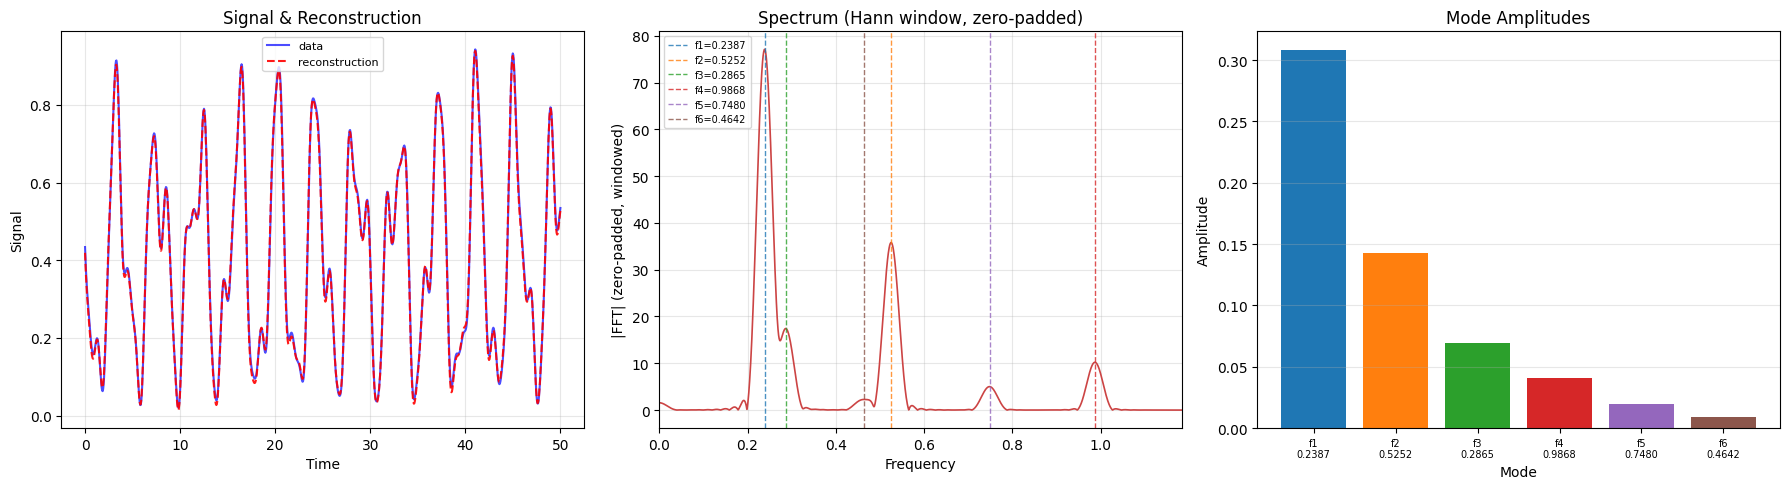

Reconstruction residual RMS: 0.0091  (signal RMS: 0.2469, ratio: 0.037)

  #       Frequency     Amplitude   Phase (rad)   Phase (deg)
------------------------------------------------------------
  1        0.238729      0.308095        1.0884       62.3593
  2        0.525205      0.143089        2.3507      134.6844
  3        0.286506      0.069662        1.3726       78.6444
  4        0.986762      0.040835        4.0788      233.7002
  5        0.748015      0.020051        2.9851      171.0354
  6        0.464178      0.009090        1.3027       74.6410


In [8]:
experimental_freqs, experimental_amps, experimental_phases = fourier_analysis(pc_list, tw_l, n_peaks= (2**nqubits)*(2**nqubits -1)//2)

## Comparison with exact Hamiltonian

Including functions to present results nicely


                     Matched energy differences                     
--------------------------------------------------------------------
   #     Detected Δε         True Δε           Error       Error (%)
--------------------------------------------------------------------
   1        1.499979        1.500000       -0.000021          -0.001%
   2        3.299961        3.300000       -0.000039          -0.001%
   3        1.800170        1.800000       +0.000170          +0.009%
   4        6.200011        6.200000       +0.000011          +0.000%
   5        4.699916        4.700000       -0.000084          -0.002%
   6        2.916517        2.900000       +0.016517          +0.570%
--------------------------------------------------------------------
                        RMS error:        0.006743


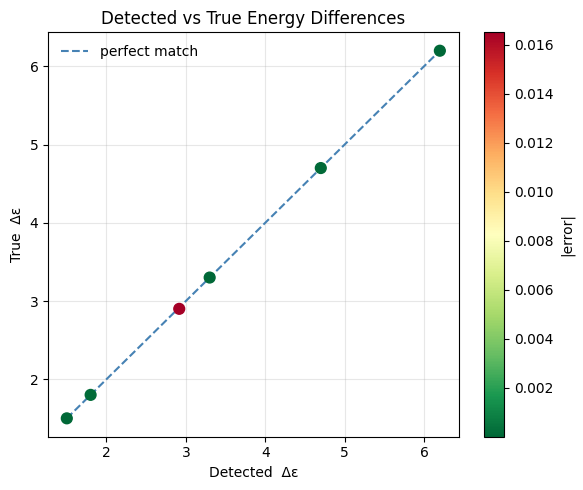

In [9]:
def table_printout(matched_detected, matched_true, residuals, true_differences, col_idx):
    # --- Nice table printout ---
    col_w = 14
    header = f"{'#':>4}  {'Detected Δε':>{col_w}}  {'True Δε':>{col_w}}  {'Error':>{col_w}}  {'Error (%)':>{col_w}}"
    sep    = "-" * len(header)
    print(f"\n{'Matched energy differences':^{len(header)}}")
    print(sep)
    print(header)
    print(sep)
    for i, (d, tr, res) in enumerate(zip(matched_detected, matched_true, residuals)):
        pct = res / tr * 100 if tr != 0 else 0.0
        print(f"{i+1:>4}  {d:{col_w}.6f}  {tr:{col_w}.6f}  {res:+{col_w}.6f}  {pct:+{col_w}.3f}%")
    print(sep)
    rms_err = np.sqrt(np.mean(residuals**2))
    print(f"{'RMS error:':>{col_w + 4 + col_w + 2}}  {rms_err:{col_w}.6f}")

    # Unmatched true differences (modes not detected)
    unmatched_true = np.delete(true_differences, col_idx)
    if len(unmatched_true) > 0:
        print(f"\nUnmatched true differences: {np.round(unmatched_true, 6)}")

def scatter_plot(matched_detected, matched_true, residuals):
    # --- Scatter plot ---
    diag_vals = np.linspace(min(matched_true.min(), matched_detected.min()),
                            max(matched_true.max(), matched_detected.max()), 100)


    plt.figure(figsize=(6, 5))
    sc = plt.scatter(matched_detected, matched_true, c=np.abs(residuals),
                    cmap='RdYlGn_r', s=60, zorder=3)
    plt.colorbar(sc, label='|error|')
    plt.plot(diag_vals, diag_vals, '--', c='steelblue', lw=1.5, label='perfect match')
    plt.xlabel('Detected  Δε')
    plt.ylabel('True  Δε')
    plt.title('Detected vs True Energy Differences')
    plt.legend(frameon=False)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

experimental_energy_diffs = 2 * np.pi * experimental_freqs

true_differences = []
for i in range(len(egvals[midpoint])):
    for j in range(i+1, len(egvals[midpoint])):
        true_differences.append(egvals[midpoint][j] - egvals[midpoint][i])
true_differences = np.array(true_differences)

# --- Nearest-neighbour matching between detected and true differences ---
from scipy.optimize import linear_sum_assignment

n_det  = len(experimental_energy_diffs)
n_true = len(true_differences)

# Cost matrix: |e_diff_i - true_diff_j|
cost = np.abs(experimental_energy_diffs[:, None] - true_differences[None, :])
row_idx, col_idx = linear_sum_assignment(cost)

matched_detected = experimental_energy_diffs[row_idx]
matched_true     = true_differences[col_idx]
residuals        = matched_detected - matched_true

table_printout(matched_detected, matched_true, residuals, true_differences, col_idx)

scatter_plot(matched_detected, matched_true, residuals)

## Solve turnpike problem to find spectrum

In [10]:
solutions = solve_incomplete_turnpike(experimental_energy_diffs, n_levels=2**nqubits)

Incomplete Turnpike Solver
  Target levels:        4
  Expected differences: 6
  Observed differences: 6 (100%)

  Trying match threshold = 100% ... found solution explaining 6/6 (100%) of observations.

  Running greedy solver for comparison...
  Greedy explains 6/6 (100%)

  Final solution (backtracking):
    [np.float64(0.0), np.float64(1.5001), np.float64(3.3), np.float64(6.2)]
    Explains 6/6 observed differences (100%)



## Compare spectrum with real one

                  E0      E1      E2      E3
True:         0.0000  1.5000  3.3000  6.2000
Recovered:    0.0000  1.5001  3.3000  6.2000


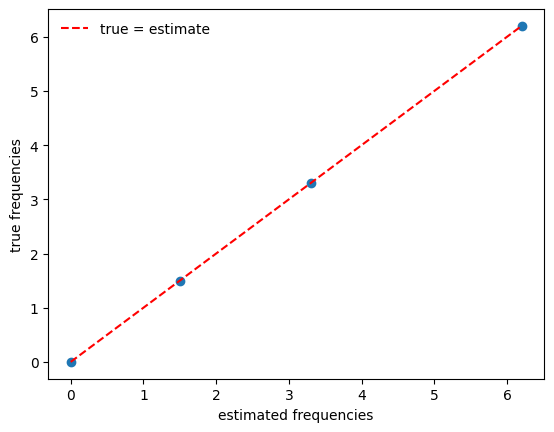

In [11]:
true_energies = egvals[midpoint]
shifted_true_energies = [i - true_energies[0] for i in true_energies]
experimental_energies = solutions['levels']

col_w = 8
header = "".join(f"{'E'+str(i):>{col_w}}" for i in range(len(shifted_true_energies)))
true_row = "".join(f"{v:>{col_w}.4f}" for v in shifted_true_energies)
found_row = "".join(f"{v:>{col_w}.4f}" for v in experimental_energies)

print(f"{'':12}{header}")
print(f"{'True:':12}{true_row}")
print(f"{'Recovered:':12}{found_row}")


plt.scatter(np.sort(experimental_energies), np.sort(shifted_true_energies))
diag = np.linspace(np.min(experimental_energies), np.max(experimental_energies), 100)
plt.plot(diag, diag, "--", c="red", label="true = estimate")
plt.xlabel("estimated frequencies")
plt.ylabel("true frequencies")
plt.legend(frameon=False)

## Create Transition matrices

In [12]:
def create_transition_matrices(experimental_energies, experimental_energy_diffs, experimental_amps, experimental_phases):
    n = len(experimental_energies)
    w_mn = np.zeros((n, n))
    w_predicted = np.zeros((n, n))
    a_mn = np.zeros((n, n))
    d_mn = np.zeros((n, n))

    # Build predicted upper-triangle frequency differences
    for i in range(n - 1):
        for j in range(i + 1, n):
            w_predicted[i, j] = experimental_energies[j] - experimental_energies[i]

    # Mask: restrict search to upper triangle only (i < j).
    # Without this, the zeros in the diagonal and lower triangle contaminate
    # np.argmin for any diff > 0, causing wrong (i, j) assignments.
    upper_tri_mask = np.zeros((n, n), dtype=bool)
    for i in range(n - 1):
        for j in range(i + 1, n):
            upper_tri_mask[i, j] = True

    used = set()  # ensure each (i, j) cell is assigned at most once

    for idx, diff in enumerate(experimental_energy_diffs):
        # Distance only over upper-triangle; set everything else to inf
        dist = np.where(upper_tri_mask, np.abs(w_predicted - diff), np.inf)

        # Walk candidates in ascending distance order; skip already-used cells
        ij_pairs = [np.unravel_index(k, (n, n)) for k in np.argsort(dist, axis=None)]
        for i, j in ij_pairs:
            i, j = int(i), int(j)
            if dist[i, j] == np.inf:
                break  # no valid upper-triangle cell left
            if (i, j) not in used:
                used.add((i, j))
                a_mn[i, j] = experimental_amps[idx]
                d_mn[i, j] = experimental_phases[idx]
                w_mn[i, j] = diff
                break

    return w_mn, a_mn, d_mn, w_predicted

## Compute phases and state vector

In [26]:
from itertools import combinations
from collections import deque

def compute_u_m(a_mn):
    """
    Estimate amplitudes u_m from the transition amplitude matrix a_mn.

    For each level m, search over all pairs (n, o) of other levels for one
    where all three matrix entries a[m,n], a[m,o], a[n,o] are nonzero, then use:

        u_m^4 ≈ a[m,n] * a[m,o] / (2 * a[n,o])

    (upper-triangle convention: always index as a[min(i,j), max(i,j)])

    If no valid pair exists for a given m (too many missing frequencies),
    u_m[m] is set to NaN and a warning is printed.

    Parameters
    ----------
    a_mn : np.ndarray, shape (N, N)
        Upper-triangular transition amplitude matrix from create_transition_matrices.

    Returns
    -------
    u_m : np.ndarray, shape (N,)
    """
    N = a_mn.shape[0]
    levels = list(range(N))
    u_m = np.full(N, np.nan)

    for m in levels:
        others = [k for k in levels if k != m]
        found = False
        for n, o in combinations(others, 2):
            a_mn_val = a_mn[min(m, n), max(m, n)]
            a_mo_val = a_mn[min(m, o), max(m, o)]
            a_no_val = a_mn[min(n, o), max(n, o)]
            if a_mn_val != 0 and a_mo_val != 0 and a_no_val != 0:
                u_m[m] = (a_mn_val * a_mo_val / (2 * a_no_val)) ** 0.25
                found = True
                break
        if not found:
            print(f"Warning: no valid triangle found for m={m}; u_m[{m}] set to NaN.")

    return u_m


def compute_phi_m(d_mn):
    """
    Estimate phases phi_m = (phi_m - phi_0) / 2  mod pi for each level m,
    using BFS over the graph of available (nonzero) entries in d_mn.

    d_mn[i,j] encodes 2*(phi_j - phi_i) for the detected transition (i < j).
    Traversing edge i->j adds  +d_mn[i,j]/2.
    Traversing edge j->i adds  -d_mn[i,j]/2.

    BFS from node 0 finds the shortest (fewest hops) path to every reachable
    node and accumulates phase differences along the way.  phi_0 is fixed to 0.

    If a node is unreachable (its subgraph is disconnected from 0), phi_m is
    set to NaN and a warning is printed.

    Parameters
    ----------
    d_mn : np.ndarray, shape (N, N)
        Upper-triangular phase matrix from create_transition_matrices.

    Returns
    -------
    phi_m : np.ndarray, shape (N,)  — phases mod pi, phi_0 = 0
    """
    N = d_mn.shape[0]
    phi_m = np.full(N, np.nan)
    phi_m[0] = 0.0

    visited = [False] * N
    visited[0] = True
    queue = deque([0])

    while queue:
        node = queue.popleft()
        for neighbor in range(N):
            if visited[neighbor]:
                continue
            i, j = min(node, neighbor), max(node, neighbor)
            if d_mn[i, j] == 0:
                continue  # edge missing
            # sign: +d/2 if traversing i->j (node==i), -d/2 if j->i (node==j)
            sign = +1 if node == i else -1
            phi_m[neighbor] = (phi_m[node] + sign * d_mn[i, j] / 2) % np.pi
            visited[neighbor] = True
            queue.append(neighbor)

    for m in range(N):
        if np.isnan(phi_m[m]):
            print(f"Warning: node {m} is unreachable from node 0; phi_m[{m}] set to NaN.")

    return phi_m


w_mn, a_mn, d_mn, w_predicted = create_transition_matrices(experimental_energies, experimental_energy_diffs, experimental_amps, experimental_phases)

e_m = w_mn[0]
u_m = compute_u_m(a_mn)
phi_m = compute_phi_m(d_mn)

print(f"e_m:   {np.array2string(np.array(e_m),   precision=4, suppress_small=True)}")
print(f"phi_m: {np.array2string(np.array(phi_m), precision=4, suppress_small=True)}")
print(f"u_m:   {np.array2string(np.array(u_m),   precision=4, suppress_small=True)}")

e_m:   [0.  1.5 3.3 6.2]
phi_m: [0.     0.5442 1.1753 2.0394]
u_m:   [0.75   0.5233 0.3566 0.1909]


## Validate state vector

In [27]:
wait_final = 0
validation_exp =LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, wait_final)

n_steps = int((ramp_time*2)*5000)

simulation = validation_exp.time_evolution(n_steps)

final_state = simulation.states[n_steps//2].full().flatten()

target_H = validation_exp.build_Ht_numpy()

egvals, egvecs = np.linalg.eigh(target_H)

u_exact = egvecs.conj().T @ final_state
u_exact_amplitudes = np.abs(u_exact)
u_exact_phases = np.angle(u_exact)
# Phases only recoverable mod π, referenced to u_0
u_exact_phases_rel = (-(u_exact_phases - u_exact_phases[0])) % np.pi

print(u_exact_amplitudes)
print(u_exact_phases_rel)

[0.74873578 0.52461757 0.35738021 0.19092019]
[0.         0.52992931 1.16660127 2.02038506]


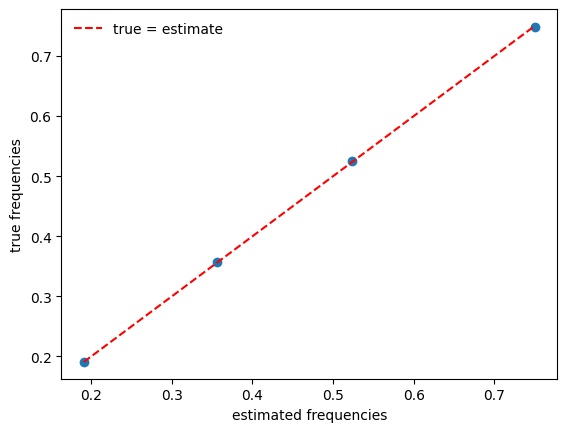

In [28]:
plt.scatter(np.sort(u_m), np.sort(u_exact_amplitudes))
diag = np.linspace(np.min(u_m), np.max(u_m), 100)
plt.plot(diag, diag, "--", c="red", label="true = estimate")
plt.xlabel("estimated frequencies")
plt.ylabel("true frequencies")
plt.legend(frameon=False)

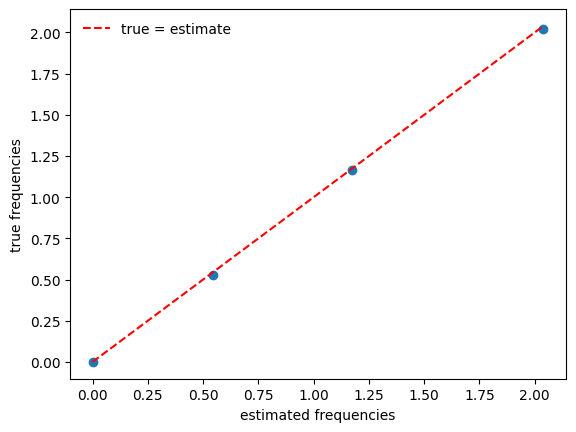

In [29]:
plt.scatter(np.sort(phi_m), np.sort(u_exact_phases_rel))
diag = np.linspace(np.min(phi_m), np.max(phi_m), 100)
plt.plot(diag, diag, "--", c="red", label="true = estimate")
plt.xlabel("estimated frequencies")
plt.ylabel("true frequencies")
plt.legend(frameon=False)

## Next steps:

0. Fixed code to do the right thing --DONE

1. Extract frequency and epsilon from oscillations --DONE

2. Test for 2 qubit system. Modify class to take in number of qubits external target Hamiltonian --DONE

3. Test interferometry for 2, 3 qubit systems --DONE

4. Look at ordering of energies, like how Matthias does it --DONE

5.  Solve turnpike problem --DONE

6. Extract phases and amplitudes from Fourier analysis --DONE

7. Verify phases and amplitudes --DONE

8. Fix phases and amplitudes when information is incomplete

7. Add dephasing noise

8. Open questions

In [17]:
# experimental_freqs, amplitudes = fourier_analysis(pc_list, tw_l, n_peaks = (2**nqubits)*(2**nqubits -1)//2)

# def fourier_analysis(pc_list, tw_l, n_peaks=15, prominence_threshold=0.01):
#     """
#     Fourier analysis extracting all significant frequencies.
    
#     Parameters
#     ----------
#     pc_list : array-like
#         Signal (e.g. ground state population over time).
#     tw_l : array-like
#         Time axis.
#     n_peaks : int
#         Maximum number of peaks to return.
#     prominence_threshold : float
#         Peaks below this fraction of the dominant peak magnitude are ignored.
    
#     Returns
#     -------
#     experimental_freqs : np.ndarray
#         Frequencies of the identified peaks, sorted by magnitude (descending).
#     amplitudes : np.ndarray
#         Corresponding amplitudes.
#     """
#     from scipy.signal import find_peaks

#     y = np.array(pc_list)
#     t = np.array(tw_l)
    
#     N = len(y)
#     dt = t[1] - t[0]
    
#     # FFT over positive frequencies only (skip DC at index 0)
#     spectrum = np.fft.fft(y)
#     freqs = np.fft.fftfreq(N, dt)
#     magnitude = np.abs(spectrum)
    
#     pos_idx = np.where(freqs > 0)[0]
#     pos_freqs = freqs[pos_idx]
#     pos_mag = magnitude[pos_idx]
    
#     # Find all local peaks — low distance/prominence to avoid missing broad peaks
#     peak_locs, _ = find_peaks(pos_mag, distance=1, prominence=0.01 * pos_mag.max())
#     if len(peak_locs) == 0:
#         peak_locs = np.array([np.argmax(pos_mag)])
    
#     # Filter by prominence relative to the dominant peak
#     threshold = prominence_threshold * pos_mag[peak_locs].max()
#     peak_locs = peak_locs[pos_mag[peak_locs] >= threshold]
    
#     # Sort by magnitude descending and take top n_peaks
#     order = np.argsort(pos_mag[peak_locs])[::-1]
#     peak_locs = peak_locs[order[:n_peaks]]
    
#     experimental_freqs = pos_freqs[peak_locs]
#     amplitudes = 2 * pos_mag[peak_locs] / N

#     # x-axis: crop just past the highest detected frequency
#     x_max = experimental_freqs.max() * 1.15

#     # --- Plots ---
#     plt.figure(figsize=(12, 5))
    
#     plt.subplot(1, 2, 1)
#     plt.plot(t, y, 'b-', linewidth=2)
#     plt.xlabel('Time')
#     plt.ylabel('Signal')
#     plt.title('Original Signal')
#     plt.grid(True, alpha=0.3)
    
#     plt.subplot(1, 2, 2)
#     plt.plot(pos_freqs, pos_mag, 'r-', linewidth=1.5)
#     colors = plt.cm.tab10.colors
#     # for i, (f, a) in enumerate(zip(experimental_freqs, amplitudes)):
#     #     plt.axvline(f, color=colors[i % len(colors)], linestyle='--',
#     #                 label=f'f{i+1}={f:.4f}, A={a:.4f}')
#     plt.xlabel('Frequency')
#     plt.ylabel('Magnitude')
#     plt.xlim(0, x_max)
#     plt.title('Fourier Transform')
#     #plt.legend(fontsize=8)
#     plt.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()
    
#     print("Identified frequencies:")
#     for i, (f, a) in enumerate(zip(experimental_freqs, amplitudes)):
#         print(f"  f{i+1} = {f:.6f},  amplitude = {a:.6f}")
    
#     return experimental_freqs, amplitudes
